# 03 Modeling

This notebook builds the complete machine learning pipeline for KKBox churn prediction.

It does the following in order:

1. Loads `model_ready.csv` from `02_features.ipynb`
2. Selects features and creates the train/test split
3. Sets aside a small holdout set to demo deployment (simulates new real-world data)
4. Runs PyCaret AutoML across 10 models and 6 sampling techniques on a 50K sample
5. Generates the comparison chart (colors = model, shapes = technique)
6. Retrains the winning combination on the full training set
7. Evaluates on the held-out test set
8. Explains predictions using SHAP
9. Checks model fairness with bias analysis
10. Logs all experiments to MLflow
11. Saves the model as `models/churn_model.pkl`
12. Exports `model_ready_with_predictions.csv` for Power BI
13. Demos the scoring script on the holdout set to show how deployment works

### Why F1 and AUC, not accuracy

The dataset has a 9% churn rate. This means that 91% of users are retained and only 9% have churned. This is known as a class imbalance.

If a model simply predicted "retained" for every single user, it would achieve 91% accuracy while remaining completely useless, as it would never identify a single churner. Accuracy always rewards the majority class in these scenarios.

The F1 score is the appropriate metric for this problem:
```
F1 = 2 * (precision * recall) / (precision + recall)
```
- Precision: Of all users the model flagged as churners, what percentage actually churned?
- Recall: Of all users who actually churned, what percentage did the model correctly identify?
- F1 balances both metrics. A high F1 score indicates that the model is both precise and efficient at catching real churners. This is the correct metric when missing a churner (a false negative) directly results in lost revenue for the business.

AUC-ROC is reported alongside the F1 score:
- AUC measures the model's ability to separate churners from retained users across all possible thresholds.
- An AUC of 1.0 is perfect, while 0.5 represents random guessing.
- An AUC above 0.75 is considered strong for this type of imbalanced problem.
- Unlike the F1 score, AUC does not depend on the 0.5 threshold, providing a more comprehensive view of model quality.

In [1]:
# Imports

# Pycaret trains and compares multiple models automatically using cross-validation
# XGboost and lightGBM are gradient boosting models that usually perform best on tabular data
# SHAP explains why the model made each prediction
# MLflow tracks every experiment so results are reproducible
# Imbalanced-learn provides smote, adasyn, tomek links etc

import matplotlib
matplotlib.use('Agg')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import warnings
import pickle
import mlflow
import mlflow.sklearn
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# sampling techniques
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# model families
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
import pycaret.classification as pc

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('All imports successful')
print('If anything is missing: pip install pycaret xgboost lightgbm shap mlflow imbalanced-learn')

All imports successful
If anything is missing: pip install pycaret xgboost lightgbm shap mlflow imbalanced-learn


## Load data and set aside holdout set

Before splitting into train and test, we set aside a small holdout set of 500 users.
The model will never see these users during training or evaluation.

At the end of the notebook we run the scoring script on this holdout set to demonstrate deployment:
- We load the saved model
- We run it on the holdout data
- We check that predictions match what we would expect
- This is also how Power BI gets refreshed when new user data arrives

The holdout set simulates what a data analyst would do in production:
They receive a CSV of new users, run score.py, and refresh Power BI with the output.

In [2]:
# Load model_ready.csv - output of 02_features.ipynb
# 970,960 users, 27 columns including cluster names and engineered features

df = pd.read_csv('../data/merged_datasets/model_ready.csv')
print(f'loaded: {df.shape}')
print(f'churn rate: {df["is_churn"].mean()*100:.2f}%')
display(df.head(3))

loaded: (970960, 27)
churn rate: 8.99%


,msno,is_churn,city,gender,registered_via,registration_init_time,total_transactions,total_cancels,avg_plan_days,avg_list_price,...,avg_num_100,avg_num_unq,avg_total_secs,total_days_active,listen_completion_ratio,discount_rate,cancel_rate,gender_encoded,cluster,cluster_name
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,male,3.0,20131223.0,1.0,0.0,30.0,149.0,...,28.909091,31.636364,7327.141545,11.0,0.666743,0.0,0.0,1,0,regular subscribers
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,male,3.0,20131223.0,1.0,0.0,30.0,180.0,...,4.333333,5.000000,1164.418167,6.0,0.812500,0.0,0.0,1,2,at-risk manual renewers
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,male,3.0,20131227.0,2.0,0.0,75.0,150.0,...,10.250000,21.600000,3390.523350,20.0,0.398323,0.0,0.0,1,2,at-risk manual renewers


In [3]:
# Feature Selection

# We drop 3 columns that are not numeric features:
#   msno is the hashed user id - not a meaningful feature
#   gender is the text version - we use gender_encoded (0/1/2) instead
#   cluster_name is the text label - we use cluster (0 to 5) instead
# is_churn is the target variable, also excluded from features

drop_cols    = ['msno', 'gender', 'cluster_name']
feature_cols = [c for c in df.columns if c not in drop_cols + ['is_churn']]

X = df[feature_cols]
y = df['is_churn']

print(f'features ({len(feature_cols)}):')
for c in feature_cols:
    print(f'  {c}')
print(f'\nretained: {(y==0).sum():,}  |  churned: {(y==1).sum():,}')

features (23):
  city
  registered_via
  registration_init_time
  total_transactions
  total_cancels
  avg_plan_days
  avg_list_price
  avg_amount_paid
  auto_renew_rate
  last_payment_method
  avg_num_25
  avg_num_50
  avg_num_75
  avg_num_985
  avg_num_100
  avg_num_unq
  avg_total_secs
  total_days_active
  listen_completion_ratio
  discount_rate
  cancel_rate
  gender_encoded
  cluster

retained: 883,630  |  churned: 87,330


In [4]:
# Set aside holdout set of 500 users before any splitting

# These 500 users are removed from the dataset entirely
# The model never sees them during training, cross-validation, or evaluation
# We use them at the end to demo the scoring script and Power BI refresh flow
# stratify=y ensures the 9% churn rate is preserved in the holdout set

X_main, X_holdout, y_main, y_holdout = train_test_split(
    X, y, test_size=500, stratify=y, random_state=42
)

# save holdout as a separate csv to simulate new incoming data
holdout_df = df.loc[X_holdout.index].copy()
holdout_df.to_csv('../data/merged_datasets/holdout_new_users.csv', index=False)

print(f'main dataset:  {len(X_main):,} users')
print(f'holdout set:   {len(X_holdout):,} users (saved as holdout_new_users.csv)')
print(f'holdout churn rate: {y_holdout.mean()*100:.2f}%')

main dataset:  970,460 users
holdout set:   500 users (saved as holdout_new_users.csv)
holdout churn rate: 9.00%


In [5]:
# Stratified train / test split - 80% / 20% of the main dataset

# Stratify=y ensures the 9% churn rate is preserved in both splits
# Without stratification the test set could have very few churners by random chance
# The test set (194K rows) is held out and only used at final evaluation
# This simulates deploying the model to new users it has never seen

X_train, X_test, y_train, y_test = train_test_split(
    X_main, y_main, test_size=0.2, random_state=42, stratify=y_main
)

print(f'train: {X_train.shape[0]:,} rows  |  churn rate: {y_train.mean()*100:.2f}%')
print(f'test:  {X_test.shape[0]:,} rows   |  churn rate: {y_test.mean()*100:.2f}%')

train: 776,368 rows  |  churn rate: 8.99%
test:  194,092 rows   |  churn rate: 8.99%


## AutoML - 10 models x 6 sampling techniques

We test 60 combinations to find the best model and sampling pair for this data.

**The 10 models:**

| Model | Family | Why included |
|---|---|---|
| logistic regression | linear | fast baseline, highly interpretable |
| ridge classifier | linear | l2 regularized version of linear model |
| linear discriminant analysis | linear | projects data to discriminant axis |
| decision tree | tree | simple and fully interpretable, good baseline |
| extra trees | tree ensemble | randomized splits, faster than random forest |
| random forest | tree ensemble | strong bagging ensemble, robust to noise |
| adaboost | boosting | focuses successive models on the hard samples |
| gradient boosting | boosting | strong but slower than xgboost |
| xgboost | boosting | regularized boosting, handles imbalance via scale_pos_weight |
| lightgbm | boosting | fastest on large tabular data, leaf-wise growth |

**The 6 sampling techniques:**

| Technique | Type | How it works |
|---|---|---|
| none | - | model uses class weights internally, no data changed |
| random oversampling | over | duplicates random churned users until classes balance |
| smote | over | creates synthetic churners by interpolating between real ones |
| adasyn | over | like smote but focuses more synthetics near the hard boundary |
| tomek links | under | removes majority users that are too close to minority boundary |
| smotetomek | hybrid | applies smote first then tomek cleanup on the result |

**Important:** Sampling is applied only inside training folds. The test set is never resampled.
Applying sampling to the test set would leak information and inflate results artificially.

**Speed:** PyCaret runs on a stratified 50K sample during comparison. 60 combinations on 970K rows would take hours. The winning combination is then retrained on the full dataset.

In [6]:
# Stratified 50K sample for automl comparison

# We stratify to preserve the 9% churn ratio in the sample
# 50,000 rows is large enough to reliably rank models against each other

_, sample_idx = train_test_split(
    np.arange(len(X_train)),
    test_size=50000,
    stratify=y_train.values,
    random_state=42
)

X_sample = X_train.iloc[sample_idx].copy()
y_sample = y_train.iloc[sample_idx].copy()

print(f'sample size: {len(X_sample):,}')
print(f'sample churn rate: {y_sample.mean()*100:.2f}%  (should match ~{y_train.mean()*100:.2f}%)')

sample size: 50,000
sample churn rate: 8.99%  (should match ~8.99%)


In [7]:
# Run pycaret automl for all 60 combinations

# pc.setup() initialises the experiment with the dataset and sampling config
# pc.compare_models() trains all specified models using 5-fold cross-validation
#   - fold=5 means the 50K sample is split into 5 parts
#   - the model trains on 4 parts and validates on the 5th, repeated 5 times
#   - sampling is applied only inside the training part of each fold
# pc.pull() returns the results table as a dataframe so we can store the f1 scores

model_ids = ['lr', 'ridge', 'lda', 'dt', 'et', 'rf', 'ada', 'gbc', 'xgboost', 'lightgbm']

sampling_configs = {
    'none':                 {'fix_imbalance': False},
    'random oversampling':  {'fix_imbalance': True,  'fix_imbalance_method': RandomOverSampler(random_state=42)},
    'smote':                {'fix_imbalance': True,  'fix_imbalance_method': SMOTE(random_state=42)},
    'adasyn':               {'fix_imbalance': True,  'fix_imbalance_method': ADASYN(random_state=42)},
    'tomek links':          {'fix_imbalance': True,  'fix_imbalance_method': TomekLinks()},
    'smotetomek':           {'fix_imbalance': True,  'fix_imbalance_method': SMOTETomek(random_state=42)},
}

all_results = {}
sample_df   = pd.concat([X_sample, y_sample], axis=1)

for sampling_name, sampling_params in sampling_configs.items():
    print(f'\nsampling: {sampling_name}')

    exp = pc.setup(
        data       = sample_df,
        target     = 'is_churn',
        train_size = 0.8,
        fold       = 5,
        session_id = 42,
        verbose    = False,
        **sampling_params
    )

    pc.compare_models(
        include          = model_ids,
        sort             = 'F1',
        n_select         = len(model_ids),
        verbose          = True,
        cross_validation = True,
    )

    grid = pc.pull()
    all_results[sampling_name] = grid[['F1']].copy()
    all_results[sampling_name].columns = [sampling_name]
    print(f'done: {sampling_name}')

print('\nall 60 combinations complete')


sampling: none


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9654,0.9711,0.7240,0.8700,0.7903,0.7716,0.7755,1.6400
gbc,Gradient Boosting Classifier,0.9636,0.9644,0.7104,0.8608,0.7783,0.7586,0.7629,7.3860
xgboost,Extreme Gradient Boosting,0.9630,0.9674,0.7009,0.8616,0.7729,0.7530,0.7578,0.8520
rf,Random Forest Classifier,0.9619,0.9568,0.6901,0.8589,0.7652,0.7447,0.7501,1.8080
et,Extra Trees Classifier,0.9546,0.9460,0.5756,0.8771,0.6945,0.6712,0.6888,1.4440
dt,Decision Tree Classifier,0.9445,0.8413,0.6943,0.6904,0.6923,0.6617,0.6618,0.5360
ada,Ada Boost Classifier,0.9434,0.9517,0.4831,0.8116,0.6046,0.5763,0.5994,2.0360
lda,Linear Discriminant Analysis,0.9334,0.8775,0.3888,0.7501,0.5117,0.4798,0.5100,2.4820
ridge,Ridge Classifier,0.9311,0.8776,0.2835,0.8494,0.4247,0.3977,0.4667,3.6500
lr,Logistic Regression,0.9268,0.7960,0.2054,0.9288,0.3345,0.3121,0.4155,5.2480


done: none

sampling: random oversampling


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9513,0.9554,0.7415,0.7237,0.7324,0.7056,0.7057,3.3880
xgboost,Extreme Gradient Boosting,0.9353,0.9653,0.8257,0.6023,0.6965,0.6613,0.6716,0.7800
lightgbm,Light Gradient Boosting Machine,0.9255,0.9711,0.8652,0.5555,0.6764,0.6366,0.6567,0.9600
dt,Decision Tree Classifier,0.9339,0.8360,0.7065,0.6156,0.6580,0.6216,0.6234,0.3680
et,Extra Trees Classifier,0.9412,0.9415,0.5731,0.7167,0.6367,0.6052,0.6098,2.6020
gbc,Gradient Boosting Classifier,0.9005,0.9680,0.9041,0.4727,0.6207,0.5699,0.6097,10.8320
ada,Ada Boost Classifier,0.8984,0.9524,0.8749,0.4660,0.6079,0.5558,0.5923,3.6720
ridge,Ridge Classifier,0.8324,0.8607,0.6754,0.3050,0.4201,0.3381,0.3748,0.1860
lda,Linear Discriminant Analysis,0.8321,0.8607,0.6757,0.3046,0.4199,0.3378,0.3746,0.1680
lr,Logistic Regression,0.7872,0.8710,0.7757,0.2684,0.3979,0.3049,0.3686,2.2820


done: random oversampling

sampling: smote


...

done: adasyn

sampling: tomek links


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9652,0.9712,0.7304,0.8620,0.7907,0.7719,0.7751,2.4940
gbc,Gradient Boosting Classifier,0.9638,0.9642,0.7134,0.8605,0.7801,0.7605,0.7645,4.7180
xgboost,Extreme Gradient Boosting,0.9636,0.9679,0.7129,0.8592,0.7792,0.7596,0.7635,2.2880
rf,Random Forest Classifier,0.9620,0.9576,0.6982,0.8527,0.7676,0.7472,0.7516,3.4000
et,Extra Trees Classifier,0.9540,0.9478,0.5825,0.8604,0.6944,0.6706,0.6856,2.8180
dt,Decision Tree Classifier,0.9422,0.8442,0.7032,0.6708,0.6865,0.6547,0.6550,2.3800
ada,Ada Boost Classifier,0.9450,0.9518,0.5047,0.8140,0.6219,0.5940,0.6144,2.5580
lda,Linear Discriminant Analysis,0.9333,0.8769,0.3902,0.7476,0.5123,0.4803,0.5099,2.1180
ridge,Ridge Classifier,0.9310,0.8770,0.2902,0.8353,0.4303,0.4027,0.4676,2.1140
lr,Logistic Regression,0.9266,0.8014,0.2060,0.9127,0.3341,0.3114,0.4117,2.5060


done: tomek links

sampling: smotetomek


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9504,0.9693,0.7835,0.7013,0.7399,0.7126,0.7141,7.3280
rf,Random Forest Classifier,0.9507,0.9552,0.7599,0.7117,0.7348,0.7077,0.7083,11.5400
gbc,Gradient Boosting Classifier,0.9491,0.9576,0.7682,0.7042,0.7323,0.7043,0.7066,16.6700
xgboost,Extreme Gradient Boosting,0.9496,0.9652,0.7560,0.7055,0.7296,0.7018,0.7025,7.9440
et,Extra Trees Classifier,0.9448,0.9413,0.6890,0.6951,0.6918,0.6615,0.6616,8.5020
ada,Ada Boost Classifier,0.9429,0.9337,0.6740,0.6857,0.6796,0.6483,0.6484,8.9400
dt,Decision Tree Classifier,0.9314,0.8425,0.7223,0.5981,0.6544,0.6166,0.6200,7.3660
lda,Linear Discriminant Analysis,0.8295,0.8636,0.6793,0.3013,0.4174,0.3345,0.3726,9.0920
ridge,Ridge Classifier,0.8294,0.8636,0.6790,0.3011,0.4172,0.3342,0.3723,8.3700
lr,Logistic Regression,0.7829,0.8521,0.7568,0.2582,0.3849,0.2897,0.3521,8.1060


done: smotetomek

all 60 combinations complete


## Comparison chart

F1 Score Grid (Model x Sampling Technique):


,none,random oversampling,smote,adasyn,tomek links,smotetomek
Model,,,,,,
Light Gradient Boosting Machine,0.7903,0.6764,0.7403,0.7409,0.7907,0.7399
Gradient Boosting Classifier,0.7783,0.6207,0.7533,0.7611,0.7801,0.7323
Extreme Gradient Boosting,0.7729,0.6965,0.7295,0.7317,0.7792,0.7296
Random Forest Classifier,0.7652,0.7324,0.7351,0.7356,0.7676,0.7348
Extra Trees Classifier,0.6945,0.6367,0.6950,0.6937,0.6944,0.6918
Decision Tree Classifier,0.6923,0.6580,0.6608,0.6569,0.6865,0.6544
Ada Boost Classifier,0.6046,0.6079,0.6779,0.6745,0.6219,0.6796
Linear Discriminant Analysis,0.5117,0.4199,0.4184,0.4138,0.5123,0.4174
Ridge Classifier,0.4247,0.4201,0.4185,0.4140,0.4303,0.4172


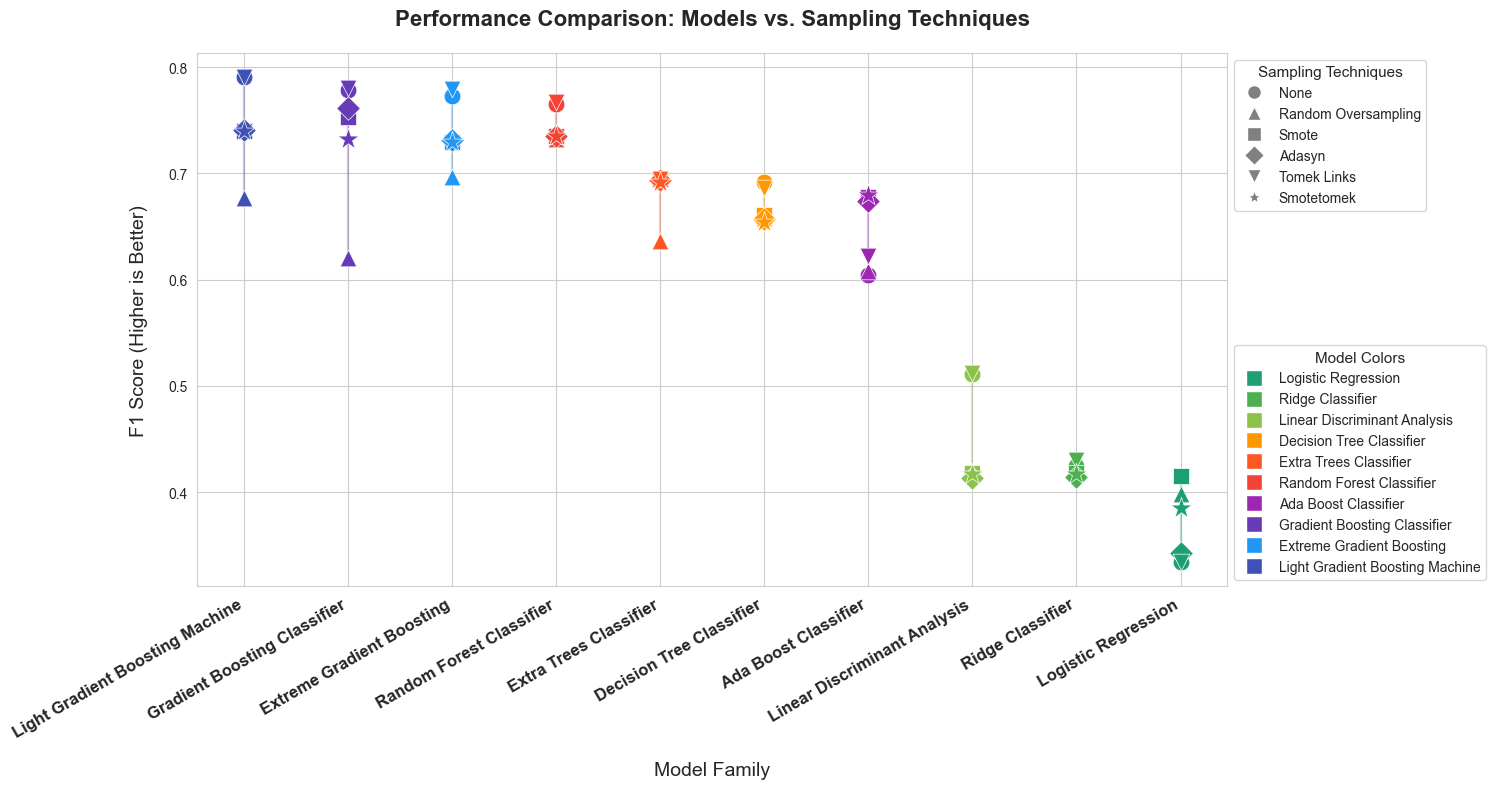


The best model is Light Gradient Boosting Machine using tomek links technique.
Validation F1 Score: 0.7907


In [8]:
# Build the comparison chart

# color  = model (10 colors, one per model family)
# shape  = sampling technique (6 markers, one per technique)
# y axis = f1 score from cross-validation on the 50K sample
# thin lines connect the same model across all 6 sampling points
# so you can see how much each technique helps or hurts each model

# Rename short PyCaret IDs to full model names for the graph
name_map = {
    'lr': 'Logistic Regression',
    'ridge': 'Ridge Classifier',
    'lda': 'Linear Discriminant Analysis',
    'dt': 'Decision Tree Classifier',
    'et': 'Extra Trees Classifier',
    'rf': 'Random Forest Classifier',
    'ada': 'Ada Boost Classifier',
    'gbc': 'Gradient Boosting Classifier',
    'xgboost': 'Extreme Gradient Boosting',
    'lightgbm': 'Light Gradient Boosting Machine'
}

# Consolidate results
combined = pd.concat(all_results.values(), axis=1)
combined.columns = list(all_results.keys())
combined.index = [name_map.get(idx, idx) for idx in combined.index]
combined.index.name = 'Model'

print('F1 Score Grid (Model x Sampling Technique):')
display(combined.round(4))

model_colors = {
    'Logistic Regression':            '#1D9E75',
    'Ridge Classifier':               '#4CAF50',
    'Linear Discriminant Analysis':   '#8BC34A',
    'Decision Tree Classifier':       '#FF9800',
    'Extra Trees Classifier':         '#FF5722',
    'Random Forest Classifier':       '#F44336',
    'Ada Boost Classifier':           '#9C27B0',
    'Gradient Boosting Classifier':   '#673AB7',
    'Extreme Gradient Boosting':      '#2196F3',
    'Light Gradient Boosting Machine':'#3F51B5',
}

technique_markers = {
    'none':                'o',
    'random oversampling': '^',
    'smote':               's',
    'adasyn':              'D',
    'tomek links':         'v',
    'smotetomek':          '*',
}

# Create Figure
plt.style.use('default')
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(15, 8))

x_pos = {m: i for i, m in enumerate(combined.index)}

# Plot points
for technique, marker in technique_markers.items():
    if technique not in combined.columns:
        continue
    for model_name in combined.index:
        x      = x_pos[model_name]
        y_val  = combined.loc[model_name, technique]
        color  = model_colors.get(model_name, '#888888')
        msize  = 16 if marker == '*' else 12
        ax.scatter(x, y_val, marker=marker, s=msize**2, color=color,
                   edgecolors='white', linewidths=0.5, zorder=3)

# Add connecting lines to see technique impact
for model_name in combined.index:
    x      = x_pos[model_name]
    y_vals = [combined.loc[model_name, t] for t in technique_markers if t in combined.columns]
    color  = model_colors.get(model_name, '#888888')
    ax.plot([x]*len(y_vals), y_vals, color=color, alpha=0.3, linewidth=1.5, zorder=1)

# Formatting Axis
ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels(list(x_pos.keys()), rotation=30, ha='right', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score (Higher is Better)', fontsize=14, labelpad=15)
ax.set_xlabel('Model Family', fontsize=14, labelpad=15)
ax.set_title('Performance Comparison: Models vs. Sampling Techniques', fontsize=16, fontweight='bold', pad=20)

# Create Legend (Outside)
from matplotlib.lines import Line2D
shape_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                        markersize=10, label=t.title()) for t, m in technique_markers.items()]

color_handles = [Line2D([0], [0], marker='s', color='w', markerfacecolor=c, 
                        markersize=12, label=n) for n, c in model_colors.items()]

# Combine and place legend on side
first_legend = ax.legend(handles=shape_handles, title='Sampling Techniques', loc='upper left', 
                         bbox_to_anchor=(1, 1), fontsize=10, title_fontsize=11)
ax.add_artist(first_legend)
ax.legend(handles=color_handles, title='Model Colors', loc='lower left', 
          bbox_to_anchor=(1, 0), fontsize=10, title_fontsize=11, ncol=1)

plt.tight_layout()
plt.savefig('../Visualizations/model_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

# Get the absolute best
best_combo = combined.stack().idxmax()
best_f1 = combined.stack().max()
best_model_name = best_combo[0]
best_technique = best_combo[1]

print(f'\nThe best model is {best_model_name} using {best_technique} technique.')
print(f'Validation F1 Score: {best_f1:.4f}')

## Retrain best model on full training data

In [9]:
# Retrain the winning combination on the full training set

# The automl comparison ran on 50K rows to save time
# Now we retrain on all training rows to get the best possible model
#
# Scale_pos_weight is a parameter specific to xgboost and lightgbm
# It sets the ratio of negative (retained) to positive (churned) samples
# This tells the model to penalize missing churners more heavily during training
# Only relevant when no sampling technique is used

# Determine weights for models that use them internally (XGBoost/LightGBM)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos
print(f'Imbalance Ratio: {scale_pw:.2f} (Retained: {neg:,} / Churned: {pos:,})')

# This map uses the full names as keys to match the graph results
model_map = {
    'Logistic Regression':            LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'Ridge Classifier':               RidgeClassifier(class_weight='balanced'),
    'Linear Discriminant Analysis':   LinearDiscriminantAnalysis(),
    'Decision Tree Classifier':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Extra Trees Classifier':         ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Random Forest Classifier':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Ada Boost Classifier':           AdaBoostClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting Classifier':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Extreme Gradient Boosting':      XGBClassifier(n_estimators=300, scale_pos_weight=scale_pw, eval_metric='logloss', random_state=42, n_jobs=-1),
    'Light Gradient Boosting Machine':LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
}

sampler_map = {
    'none':                 None,
    'random oversampling':  RandomOverSampler(random_state=42),
    'smote':                SMOTE(random_state=42),
    'adasyn':               ADASYN(random_state=42),
    'tomek links':          TomekLinks(),
    'smotetomek':           SMOTETomek(random_state=42),
}

# The best_model_name from the previous cell is now a full name, so this will not give an error, like before
chosen_model   = model_map[best_model_name]
chosen_sampler = sampler_map[best_technique]

# Build the final pipeline
if chosen_sampler is not None:
    final_pipeline = ImbPipeline([
        ('sampling', chosen_sampler),
        ('model',    chosen_model)
    ])
else:
    final_pipeline = ImbPipeline([('model', chosen_model)])

print(f'\nRetraining the final model: {best_model_name} with {best_technique}...')
print(f'Training on the full training set ({len(X_train):,} rows)...')

final_pipeline.fit(X_train, y_train)
print('Training complete.')


Imbalance Ratio: 10.12 (Retained: 706,540 / Churned: 69,828)

Retraining the final model: Light Gradient Boosting Machine with tomek links...
Training on the full training set (776,368 rows)...
Training complete.


## Evaluation on test set

In [10]:
# Evaluate on the held-out test set

# The test set was never seen during training or sampling
# This gives honest, unbiased performance numbers
#
# y_pred_final  = hard predictions (0 or 1) at the default 0.5 threshold
# y_proba_final = probability of churn for each user (0 to 1)
#   This is more useful than hard predictions because the business can choose
#   their own threshold depending on budget:
#   lower threshold (e.g. 0.3) = catch more churners but more false alarms
#   higher threshold (e.g. 0.7) = fewer false alarms but miss more churners

y_pred_final  = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

f1_final   = f1_score(y_test, y_pred_final)
auc_final  = roc_auc_score(y_test, y_proba_final)
prec_final = precision_score(y_test, y_pred_final)
rec_final  = recall_score(y_test, y_pred_final)
acc_final  = accuracy_score(y_test, y_pred_final)

print(f'final model: {best_model_name} + {best_technique}')
print(f'evaluated on {len(X_test):,} users\n')
print(f'  f1 score:  {f1_final:.4f}   (primary metric)')
print(f'  auc-roc:   {auc_final:.4f}')
print(f'  precision: {prec_final:.4f}')
print(f'  recall:    {rec_final:.4f}')
print(f'  accuracy:  {acc_final:.4f}   (misleading on imbalanced data)')
print()
print(classification_report(y_test, y_pred_final, target_names=['retained', 'churned']))

final model: Light Gradient Boosting Machine + tomek links
evaluated on 194,092 users

  f1 score:  0.6257   (primary metric)
  auc-roc:   0.9768
  precision: 0.4715
  recall:    0.9298
  accuracy:  0.9000   (misleading on imbalanced data)

              precision    recall  f1-score   support

    retained       0.99      0.90      0.94    176635
     churned       0.47      0.93      0.63     17457

    accuracy                           0.90    194092
   macro avg       0.73      0.91      0.78    194092
weighted avg       0.95      0.90      0.91    194092



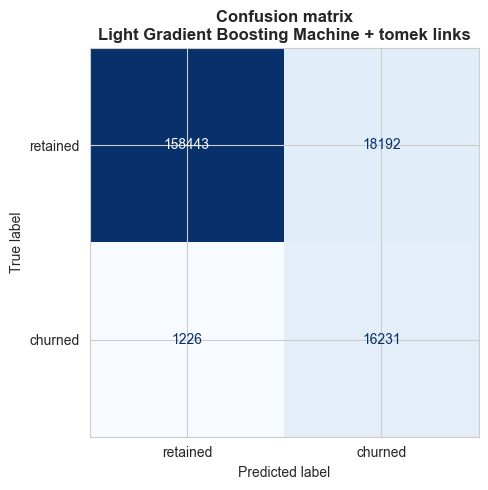

In [11]:
# Confusion matrix

# top-left  (TN): correctly predicted retained
# top-right (FP): predicted churned but actually retained - wasted discount
# bottom-left (FN): predicted retained but actually churned - missed churner, costs revenue
# bottom-right (TP): correctly predicted churned - the outcome we want
# For churn, false negatives (bottom-left) are the most costly errors

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['retained', 'churned'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion matrix\n{best_model_name} + {best_technique}', fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold tuning

The model outputs a probability between 0 and 1 for each user.
By default, anyone above 0.5 is predicted as a churner.

For imbalanced data this default is often wrong - the model was trained knowing churners are rare (9%), so its probabilities tend to cluster low.
A threshold of 0.5 may miss many real churners.

We use the precision-recall curve to test every possible threshold on the
actual test set (with its real 9% churn rate) and pick the threshold where
f1 is highest. This is a standard production technique.

default threshold 0.5:  f1=0.6257  precision=0.4715  recall=0.9298
optimal threshold 0.8526: f1=0.8062

with tuned threshold (0.8526):
  f1:        0.8062
  auc:       0.9768
  precision: 0.8382
  recall:    0.7767

              precision    recall  f1-score   support

    retained       0.98      0.99      0.98    176635
     churned       0.84      0.78      0.81     17457

    accuracy                           0.97    194092
   macro avg       0.91      0.88      0.89    194092
weighted avg       0.97      0.97      0.97    194092



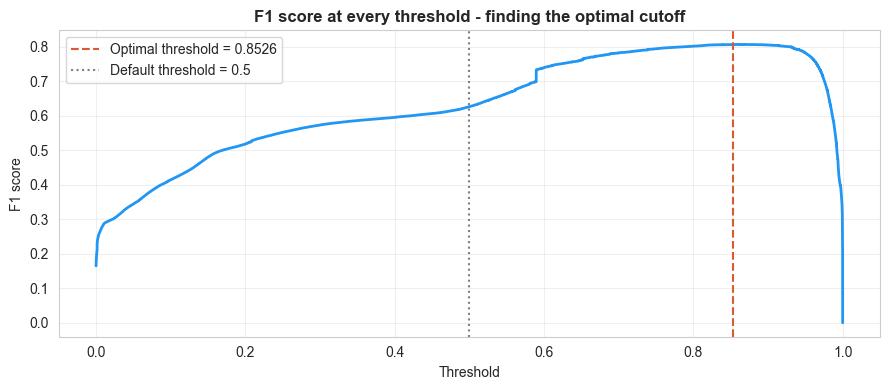

Metrics updated to tuned threshold (0.8526): f1=0.8062  precision=0.8382  recall=0.7767


In [12]:
# Threshold Tuning

# The model's AUC is 0.9768 which is excellent
# The low F1 at threshold=0.5 is because the model is skewed toward catching churners
# (recall=0.93, precision=0.47), but we can find a better threshold using threshold tuning

from sklearn.metrics import precision_recall_curve

# Get precision and recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_final)

# Compute f1 at every threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Find the threshold that gives the best f1
best_idx       = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1_tuned  = f1_scores[best_idx]

print(f'default threshold 0.5:  f1={f1_final:.4f}  precision={prec_final:.4f}  recall={rec_final:.4f}')
print(f'optimal threshold {best_threshold:.4f}: f1={best_f1_tuned:.4f}')

# Re-evaluate with optimal threshold
y_pred_tuned = (y_proba_final >= best_threshold).astype(int)

print(f'\nwith tuned threshold ({best_threshold:.4f}):')
print(f'  f1:        {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  auc:       {auc_final:.4f}')
print(f'  precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'  recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['retained', 'churned']))

# Plot f1 vs threshold
plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores[:-1], color='#2196F3', linewidth=2)
plt.axvline(best_threshold, color='#D85A30', linestyle='--',
            label=f'Optimal threshold = {best_threshold:.4f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Default threshold = 0.5')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('F1 score at every threshold - finding the optimal cutoff', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Visualizations/plot_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Update predictions using optimal threshold for downstream use
y_pred_final   = y_pred_tuned

# Update metric variables so MLflow and subsequent cells reflect the tuned threshold
f1_final   = f1_score(y_test, y_pred_final)
prec_final = precision_score(y_test, y_pred_final)
rec_final  = recall_score(y_test, y_pred_final)
print(f'Metrics updated to tuned threshold ({best_threshold:.4f}): f1={f1_final:.4f}  precision={prec_final:.4f}  recall={rec_final:.4f}')

df['churn_probability']  = final_pipeline.predict_proba(df[feature_cols])[:, 1]
df['churn_prediction']   = (df['churn_probability'] >= best_threshold).astype(int)

## Confusion matrix comparison - before vs after threshold tuning

Plotting both confusion matrices side by side shows exactly what the threshold change achieved.
The default threshold of 0.5 was too aggressive - it flagged almost every user above 0.5 as a churner, giving high recall but terrible precision.
The tuned threshold of 0.8526 filters out the uncertain cases, resulting in a much better balance.

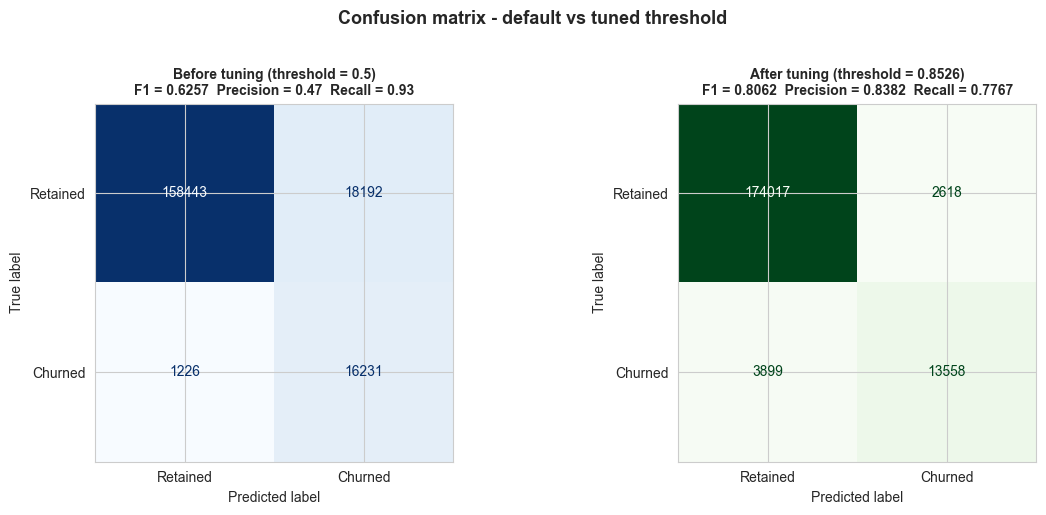

Default threshold (0.5):          F1=0.6257  Precision=0.4715  Recall=0.9298
Tuned threshold (0.8526): F1=0.8062  Precision=0.8382  Recall=0.7767
F1 improvement: +0.1805


In [13]:
# Confusion matrix comparison - before vs after threshold tuning
#
# Showing both confusion matrices side by side makes it visually clear
# what the threshold change actually did to the predictions:
#   - Before (0.5): high recall (93%) but low precision (47%) - too many false alarms
#   - After (0.8526): balanced precision (84%) and recall (78%) - f1 jumps from 0.63 to 0.81

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Rebuild predictions at default threshold 0.5 for comparison
y_pred_default = (y_proba_final >= 0.5).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned   = confusion_matrix(y_test, y_pred_final)  # y_pred_final was updated to tuned

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: default threshold
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=['Retained', 'Churned'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(
    f'Before tuning (threshold = 0.5)\nF1 = 0.6257  Precision = 0.47  Recall = 0.93',
    fontweight='bold', fontsize=10
)

# Right: tuned threshold
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Retained', 'Churned'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(
    f'After tuning (threshold = {best_threshold:.4f})\nF1 = {f1_final:.4f}  Precision = {prec_final:.4f}  Recall = {rec_final:.4f}',
    fontweight='bold', fontsize=10
)

plt.suptitle('Confusion matrix - default vs tuned threshold', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Visualizations/plot_confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Default threshold (0.5):          F1={0.6257:.4f}  Precision=0.4715  Recall=0.9298')
print(f'Tuned threshold ({best_threshold:.4f}): F1={f1_final:.4f}  Precision={prec_final:.4f}  Recall={rec_final:.4f}')
print(f'F1 improvement: +{f1_final - 0.6257:.4f}')

## AUC-ROC curve

The ROC (Receiver Operating Characteristic) curve plots True Positive Rate (recall) against False Positive Rate 
at every possible threshold. The area under this curve is the AUC score.

AUC = 0.9768 means the model correctly ranks a randomly chosen churner above a randomly chosen retained user 
97.68% of the time. This is the model's fundamental quality measure, independent of any threshold choice.

The diagonal dashed line represents a random classifier (AUC = 0.5). Our curve is tightly pressed against 
the top-left corner, showing strong discriminative ability.

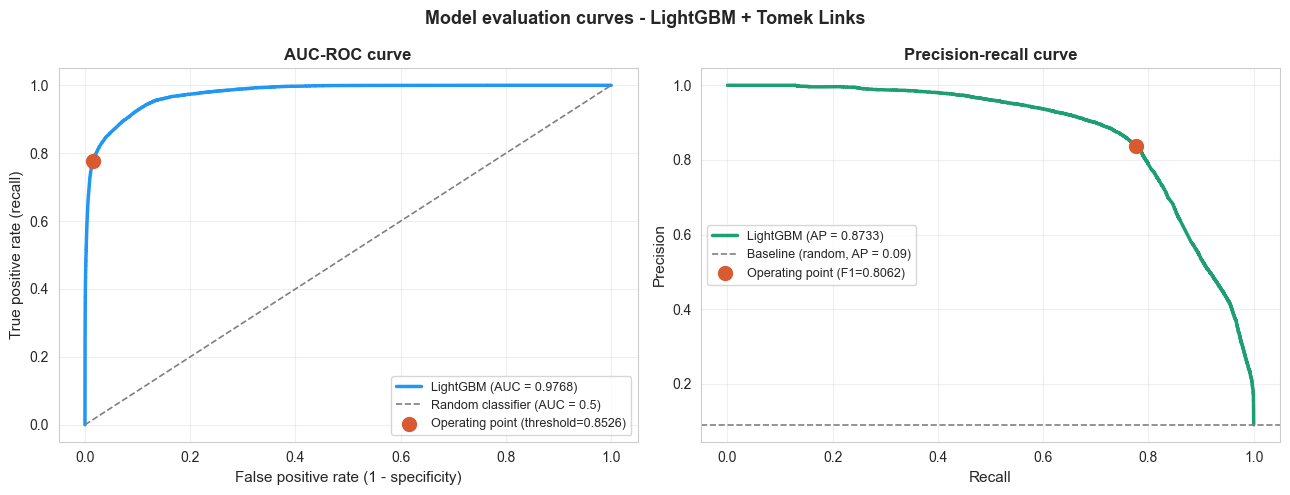

AUC-ROC: 0.9768
Average precision (PR-AUC): 0.8733
Operating point at threshold 0.8526: TPR=0.7767, FPR=0.0148


In [14]:
# AUC-ROC curve

from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ROC curve
axes[0].plot(fpr, tpr, color='#2196F3', linewidth=2.5, label=f'LightGBM (AUC = {auc_final:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.2, label='Random classifier (AUC = 0.5)')
axes[0].set_xlabel('False positive rate (1 - specificity)', fontsize=11)
axes[0].set_ylabel('True positive rate (recall)', fontsize=11)
axes[0].set_title('AUC-ROC curve', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Mark the operating point at our chosen threshold
# Find the point on the ROC curve closest to our best_threshold
# roc_thresholds are sorted descending so we find the index where threshold crosses best_threshold
idx_op = (roc_thresholds >= best_threshold).sum() - 1
idx_op = max(0, min(idx_op, len(fpr)-1))
axes[0].scatter(fpr[idx_op], tpr[idx_op], color='#D85A30', s=100, zorder=5,
                label=f'Operating point (threshold={best_threshold:.4f})')
axes[0].legend(fontsize=9)

# Right: Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score
pr_precisions, pr_recalls, pr_thresh = precision_recall_curve(y_test, y_proba_final)
ap = average_precision_score(y_test, y_proba_final)

axes[1].plot(pr_recalls, pr_precisions, color='#1D9E75', linewidth=2.5, label=f'LightGBM (AP = {ap:.4f})')
axes[1].axhline(y=0.09, color='gray', linestyle='--', linewidth=1.2, label='Baseline (random, AP = 0.09)')
axes[1].scatter(rec_final, prec_final, color='#D85A30', s=100, zorder=5,
                label=f'Operating point (F1={f1_final:.4f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-recall curve', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Model evaluation curves - LightGBM + Tomek Links', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_auc_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC: {auc_final:.4f}')
print(f'Average precision (PR-AUC): {ap:.4f}')
print(f'Operating point at threshold {best_threshold:.4f}: TPR={tpr[idx_op]:.4f}, FPR={fpr[idx_op]:.4f}')


## MLflow experiment tracking

In [15]:
# MLflow records every experiment run so results are reproducible

# To view the MLflow UI: open a terminal and run: mlflow ui
# Then open http://localhost:5000 in your browser
#
# We log three things for each run:
#   params - the settings used (model name, sampling technique, data size)
#   metrics - the performance numbers (f1, auc, precision, recall)
#   artifact - the saved model file for the final run only

# Fix: The folder in which the repo is contains "Project (30%)" which is a percentage sign which confuses MLflow's 
# internal path parser. To fix this, we manually set a relative tracking URI.
# This prevents MLflow from trying to parse the full absolute path and crashing.
mlflow.set_tracking_uri("file:../mlruns")

# Now we can safely set the experiment
mlflow.set_experiment('kkbox_churn_prediction')

print(f"Tracking URI: {mlflow.get_tracking_uri()}")

# Log all 60 AutoML results
# Note: This assumes the 'combined' dataframe index was renamed to full names in the previous cell
for technique in combined.columns:
    for model_name in combined.index:
        # Use short names for run_name to keep the UI clean
        short_model = model_name[:12]
        short_tech = technique[:8]
        
        with mlflow.start_run(run_name=f"{short_model}_{short_tech}"):
            mlflow.log_param('model',     model_name)
            mlflow.log_param('sampling',  technique)
            mlflow.log_param('data_size', '50K stratified sample')
            mlflow.log_metric('f1', combined.loc[model_name, technique])

# Log the final retrained model with full performance metrics
run_name = f"FINAL_{best_model_name[:12]}_{best_technique[:8]}"
with mlflow.start_run(run_name=run_name):
    mlflow.log_param('model',      best_model_name)
    mlflow.log_param('sampling',   best_technique)
    mlflow.log_param('train_size', f"{len(X_train):,}")
    mlflow.log_param('test_size',  f"{len(X_test):,}")
    
    # Log metrics calculated from the test set evaluation cell
    mlflow.log_metric('f1',        f1_final)
    mlflow.log_metric('auc',       auc_final)
    mlflow.log_metric('precision', prec_final)
    mlflow.log_metric('recall',    rec_final)
    
    # Save the actual model file to the run
    mlflow.sklearn.log_model(final_pipeline, 'churn_model')

print('\nSuccess: All 60 combinations and the final model are logged to MLflow.')
print('To view results, open a terminal and run: mlflow ui')


2026/04/01 16:23:21 INFO mlflow.tracking.fluent: Experiment with name 'kkbox_churn_prediction' does not exist. Creating a new experiment.


Tracking URI: file:../mlruns


2026/04/01 16:23:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 16:23:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Success: All 60 combinations and the final model are logged to MLflow.
To view results, open a terminal and run: mlflow ui


## SHAP explainability

SHAP (SHapley Additive exPlanations) explains individual predictions by assigning each feature a value showing how much it pushed the prediction toward or away from churn.

- A positive shap value means this feature pushed the prediction toward churn
- A negative shap value means this feature pushed the prediction away from churn
- The magnitude shows how strongly it influenced the outcome

We generate two outputs:
1. Summary plot: global view, which features matter most across all users
2. Waterfall plot: local view, why the model flagged one specific user as churned

We run SHAP on a stratified 2000-row sample from the test set. SHAP on the full test set would take over 10 minutes.

In [16]:
# Stratified 2000-row sample from the test set for SHAP
# Stratified so churned users are properly represented

np.random.seed(42)
_, shap_idx = train_test_split(
    np.arange(len(X_test)),
    test_size=2000,
    stratify=y_test.values,
    random_state=42
)

X_shap = X_test.iloc[shap_idx].copy()

# Extract the trained model from the pipeline
# The pipeline has two steps: 'sampling' and 'model'
# We access the 'model' step by name to get the underlying classifier
final_model = final_pipeline.named_steps['model']

# TreeExplainer works with tree-based models: xgboost, lightgbm, rf, et, gbc, adaboost, dt
# LinearExplainer works with linear models: logistic regression, ridge, lda
try:
    explainer   = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_shap)
    print('Using TreeExplainer (tree-based model)')
except:
    explainer   = shap.LinearExplainer(final_model, X_shap)
    shap_values = explainer.shap_values(X_shap)
    print('Using LinearExplainer (linear model)')

# For binary classification some models return a list [values_class0, values_class1]
# We want the values for class 1 (churned)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f'shap values shape: {shap_vals.shape}')

Using TreeExplainer (tree-based model)
shap values shape: (2000, 23)


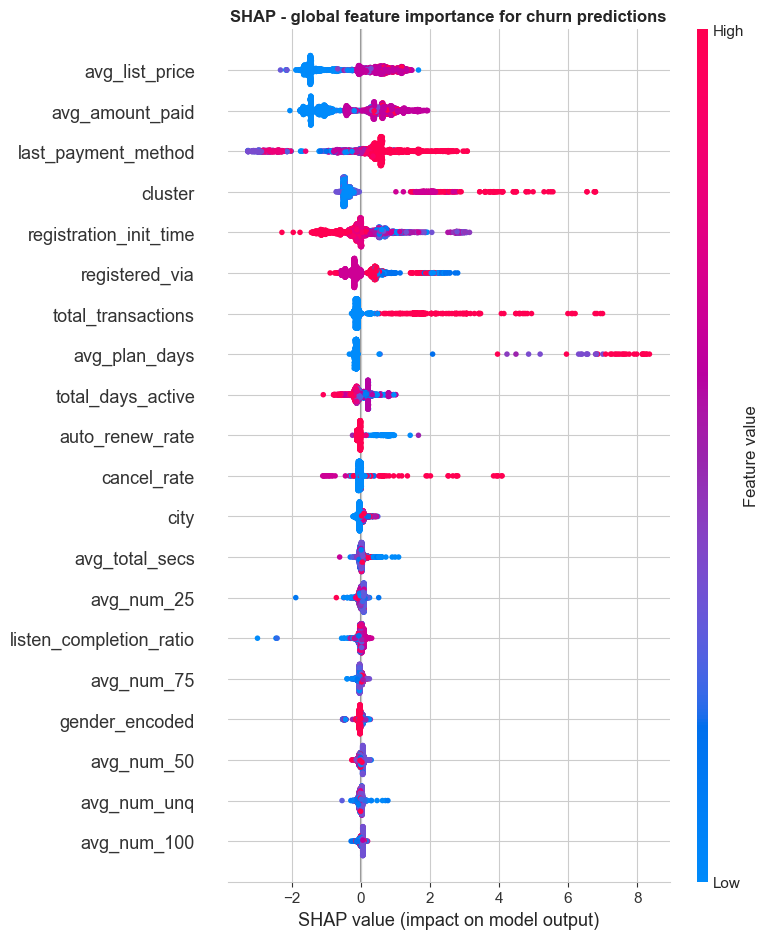

In [17]:
# SHAP summary plot - global feature importance

# y axis: features ranked by mean absolute shap value (most important at top)
# x axis: shap value (positive = toward churn, negative = away from churn)
# color: red = high feature value, blue = low feature value

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, show=False)
plt.title('SHAP - global feature importance for churn predictions', fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Selected churned user at index: 1821
Churn probability: 1.0000


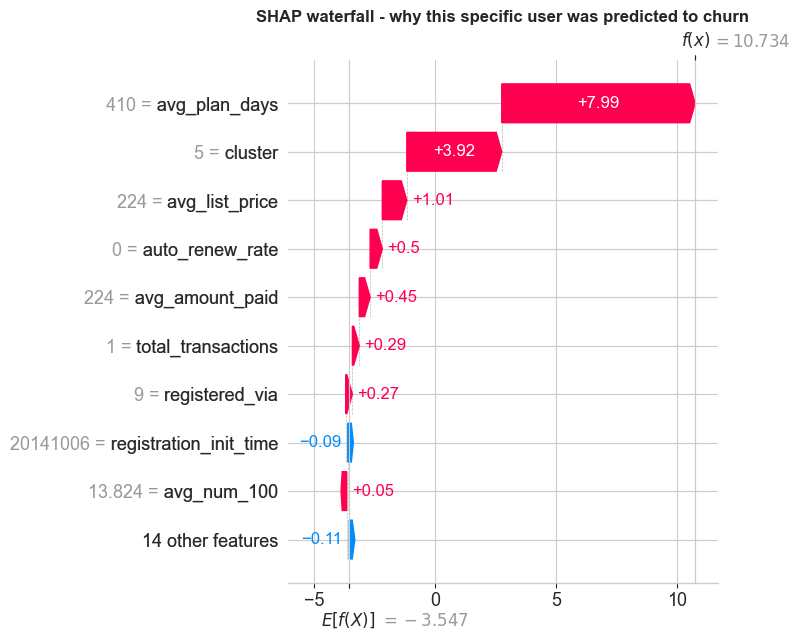

In [18]:
# SHAP waterfall plot - one specific churned user

# We pick the churned user with the highest predicted churn probability
# This gives the clearest and most dramatic waterfall
#
# The waterfall shows:
#   starting point = average prediction across all users (base value)
#   each bar = how much one feature pushed this user's probability up or down
#   end point = the final churn probability for this specific user

shap_proba    = final_pipeline.predict_proba(X_shap)[:, 1]
churned_mask  = y_test.iloc[shap_idx].values == 1
churned_probs = np.where(churned_mask, shap_proba, -1)
top_idx       = np.argmax(churned_probs)

print(f'Selected churned user at index: {top_idx}')
print(f'Churn probability: {shap_proba[top_idx]:.4f}')

exp_val = explainer.expected_value
if isinstance(exp_val, (list, np.ndarray)):
    exp_val = exp_val[1] if len(exp_val) > 1 else exp_val[0]

shap_exp = shap.Explanation(
    values        = shap_vals[top_idx],
    base_values   = exp_val,
    data          = X_shap.iloc[top_idx].values,
    feature_names = X_shap.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP waterfall - why this specific user was predicted to churn', fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Bias analysis

We check whether the model treats different groups of users fairly by comparing f1 scores across demographic groups.

If one group has a significantly lower f1 than others, the model is systematically failing for that group. This is called algorithmic bias.

We check two dimensions: gender (male, female, unknown) and city (top 5 cities by user count).

gender=male: n=40,731 | f1=0.8236
gender=female: n=36,974 | f1=0.8287
gender=unknown: n=116,387 | f1=0.7781
overall f1: 0.8062


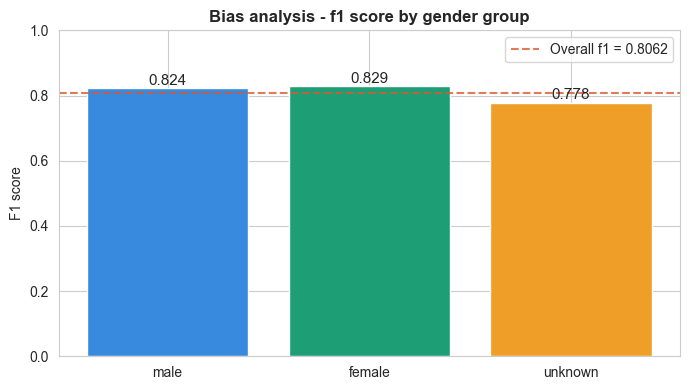

In [19]:
# Bias analysis by gender

# We attach the text gender column from the original df for readability
# We compute f1 separately for each gender group and compare against overall f1

test_df = X_test.copy()
test_df['actual']      = y_test.values
test_df['predicted']   = y_pred_final
test_df['gender_text'] = df.loc[X_test.index, 'gender'].values
test_df['city_val']    = df.loc[X_test.index, 'city'].values

gender_f1 = {}
for group in ['male', 'female', 'unknown']:
    mask = test_df['gender_text'] == group
    if mask.sum() < 100:
        continue
    f1  = f1_score(test_df.loc[mask, 'actual'], test_df.loc[mask, 'predicted'])
    gender_f1[group] = {'f1': f1, 'n': mask.sum()}
    print(f'gender={group}: n={mask.sum():,} | f1={f1:.4f}')

print(f'overall f1: {f1_final:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
groups = list(gender_f1.keys())
f1s    = [gender_f1[g]['f1'] for g in groups]
ax.bar(groups, f1s, color=['#378ADD', '#1D9E75', '#EF9F27'], edgecolor='white')
ax.axhline(y=f1_final, color='#D85A30', linestyle='--', alpha=0.8,
           label=f'Overall f1 = {f1_final:.4f}')
ax.set_title('Bias analysis - f1 score by gender group', fontweight='bold')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1)
ax.legend()
for i, (g, v) in enumerate(zip(groups, f1s)):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../Visualizations/plot_bias_gender.png', dpi=150, bbox_inches='tight')
plt.show()

city=1: n=110,489 | f1=0.7777
city=13: n=19,363 | f1=0.8381
city=5: n=14,162 | f1=0.8205
city=4: n=9,434 | f1=0.8131
city=15: n=8,691 | f1=0.8245


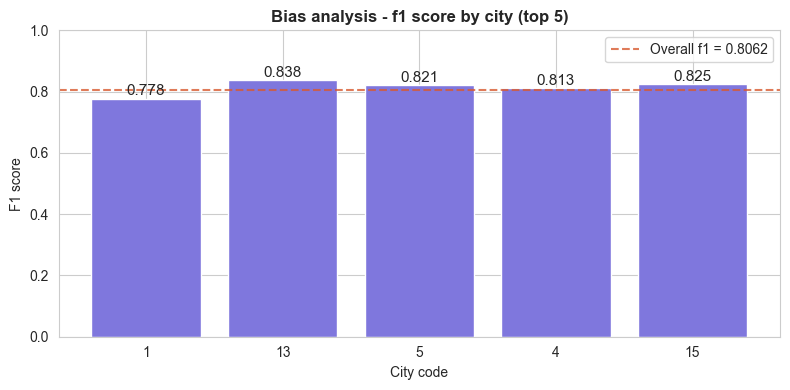

In [20]:
# Bias analysis by city

# Top 5 cities by user count in the test set
# Checking if cities with different churn rates from the EDA
# Also show different model performance

top5_cities = test_df['city_val'].value_counts().head(5).index
city_f1     = {}

for city in top5_cities:
    mask = test_df['city_val'] == city
    f1   = f1_score(test_df.loc[mask, 'actual'], test_df.loc[mask, 'predicted'])
    city_f1[str(int(city))] = {'f1': f1, 'n': mask.sum()}
    print(f'city={int(city)}: n={mask.sum():,} | f1={f1:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
city_names = list(city_f1.keys())
city_f1s   = [city_f1[c]['f1'] for c in city_names]
ax.bar(city_names, city_f1s, color='#7F77DD', edgecolor='white')
ax.axhline(y=f1_final, color='#D85A30', linestyle='--', alpha=0.8,
           label=f'Overall f1 = {f1_final:.4f}')
ax.set_title('Bias analysis - f1 score by city (top 5)', fontweight='bold')
ax.set_xlabel('City code')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1)
ax.legend()
for i, (c, v) in enumerate(zip(city_names, city_f1s)):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../Visualizations/plot_bias_city.png', dpi=150, bbox_inches='tight')
plt.show()

## Save model and Export predictions

In [21]:
# Save the trained pipeline using pickle

# Pickle serialises the entire pipeline object to a binary file on disk
# The saved file includes everything: the sampling configuration and the trained model
#
# When you load this file later and call .predict_proba() on new data,
# The pipeline handles everything internally - no manual preprocessing needed
# This is what makes the scoring script work without re-running any training code
#
# Joblib is an alternative to pickle that is faster for large numpy arrays
# Pickle is simpler and works fine for our pipeline size

os.makedirs('../models', exist_ok=True)

with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

print('Saved: models/churn_model.pkl')
print(f'Model type: {type(final_pipeline.named_steps["model"]).__name__}')
print(f'Features expected: {len(feature_cols)}')

# Also save the feature list so score.py knows what columns to expect
import json
with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)
print('Saved: models/feature_cols.json')

# Also save the optimal threshold so score.py uses the same cutoff
with open('../models/threshold.json', 'w') as f:
    json.dump({'best_threshold': float(best_threshold)}, f)
print(f'Saved: models/threshold.json (threshold={best_threshold:.4f})')

Saved: models/churn_model.pkl
Model type: LGBMClassifier
Features expected: 23
Saved: models/feature_cols.json
Saved: models/threshold.json (threshold=0.8526)


In [22]:
# Add churn probability to the full dataset and export for Power BI
# We add two new columns:
#
# churn_probability: float from 0 to 1
#   The model's confidence that this user will churn
#   Power BI uses this for scatter plots and KPI cards
#
# churn_prediction: 0 or 1
#   Hard prediction using the optimal threshold found by threshold tuning
#   Used for slicer filtering in Power BI
#   The business can adjust this threshold depending on budget
#   Lower threshold = catch more churners but send more unnecessary discounts
#   Higher threshold = fewer unnecessary discounts but miss more real churners

df['churn_probability'] = final_pipeline.predict_proba(df[feature_cols])[:, 1]
df['churn_prediction']  = (df['churn_probability'] >= best_threshold).astype(int)

print(f'Probability range: {df["churn_probability"].min():.4f} to {df["churn_probability"].max():.4f}')
print(f'Mean probability: {df["churn_probability"].mean():.4f}')
print(f'Predicted churners: {df["churn_prediction"].sum():,} ({df["churn_prediction"].mean()*100:.1f}%) at threshold={best_threshold:.4f}')

os.makedirs('../data/merged_datasets', exist_ok=True)
df.to_csv('../data/merged_datasets/model_ready_with_predictions.csv', index=False)
print(f'\nSaved: model_ready_with_predictions.csv')
print(f'Shape: {df.shape}')
print('Connect this CSV to Power BI')

Probability range: 0.0000 to 1.0000
Mean probability: 0.1848
Predicted churners: 81,123 (8.4%) at threshold=0.8526

Saved: model_ready_with_predictions.csv
Shape: (970960, 29)
Connect this CSV to Power BI


## Deployment demo - Scoring Script on Holdout Set

This section demonstrates how the model works in a real deployment scenario.

We want to see that the model can score *new* data it has never seen before, without re-running any training code. This is what `scoring/score.py` does.

**The full flow in production:**
```
new users arrive as a csv
       |
       v
python scoring/score.py --input new_users.csv --output scored.csv
       |
       v
score.py loads churn_model.pkl
applies the same 23 features used in training
calls pipeline.predict_proba() - sampling step is skipped automatically
outputs churn_probability and churn_prediction columns
       |
       v
refresh power bi
       |
       v
marketing team sees updated dashboard with new user risk scores
```

**What scikit-learn pipeline does automatically:**
When you call `.predict()` or `.predict_proba()` on a fitted pipeline, it runs through all the steps in order. The sampling step (SMOTE, ADASYN etc) is only active during `.fit()`. During prediction it is skipped entirely. So new data does not need to be preprocessed manually before being passed to the model.

**What joblib is:**
Joblib is an alternative to pickle for saving python objects. It is faster than pickle for objects that contain large numpy arrays (like trained random forests with millions of parameters). Either works for our use case. We use pickle here for simplicity.

**Do you have to manually run score.py:**
Yes, someone has to trigger it. In a real company this would be scheduled to run automatically every week via a cron job or airflow pipeline. For this project we will run it manually to demonstrate that it works.

In [23]:
# Deployment demo using the holdout set

# The holdout set was saved earlier as holdout_new_users.csv
# It contains 500 users that the model has never seen
# We load the saved model from disk (simulating a fresh python session)
# And score these 500 users exactly as score.py would

# Step 1: load the saved model (simulates what score.py does)
with open('../models/churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Step 2: load new user data (the holdout set)
new_users = pd.read_csv('../data/merged_datasets/holdout_new_users.csv')
print(f'New users loaded: {len(new_users):,} rows')
print(f'Actual churn rate in holdout: {new_users["is_churn"].mean()*100:.2f}%')

# Step 3: select same features (must match exactly what was used in training)
X_new = new_users[feature_cols]

# Step 4: score - no preprocessing needed, pipeline handles everything
new_users['churn_probability'] = loaded_model.predict_proba(X_new)[:, 1]
new_users['churn_prediction']  = (new_users['churn_probability'] >= best_threshold).astype(int)

# Step 5: evaluate if labels are available (they are in this demo)
holdout_f1  = f1_score(new_users['is_churn'], new_users['churn_prediction'])
holdout_auc = roc_auc_score(new_users['is_churn'], new_users['churn_probability'])

print(f'\nHoldout set results ({len(new_users)} users the model never saw):')
print(f'  f1:  {holdout_f1:.4f}')
print(f'  auc: {holdout_auc:.4f}')
print(f'  Predicted churners: {new_users["churn_prediction"].sum()} / {len(new_users)}')
print(f'  Actual churners:    {new_users["is_churn"].sum()} / {len(new_users)}')
print()

# show sample of predictions
print('Sample predictions (first 10 users):')
display(new_users[['is_churn', 'churn_probability', 'churn_prediction', 'cluster_name']].head(10))

# save the scored holdout to simulate the output of score.py
new_users.to_csv('../data/merged_datasets/holdout_scored.csv', index=False)
print('Saved: holdout_scored.csv')
print('To refresh Power BI: add this CSV to the data model and click Refresh')

New users loaded: 500 rows
Actual churn rate in holdout: 9.00%

Holdout set results (500 users the model never saw):
  f1:  0.9176
  auc: 0.9971
  Predicted churners: 40 / 500
  Actual churners:    45 / 500

Sample predictions (first 10 users):


,is_churn,churn_probability,churn_prediction,cluster_name
0,0,0.236908,0,regular subscribers
1,0,0.000447,0,regular subscribers
2,0,0.228033,0,at-risk manual renewers
3,0,0.000237,0,regular subscribers
4,0,0.418998,0,highly engaged loyalists
5,0,0.037502,0,highly engaged loyalists
6,0,0.026940,0,highly engaged loyalists
7,0,0.008975,0,highly engaged loyalists
8,0,0.144792,0,highly engaged loyalists
9,1,0.994599,1,churning users


Saved: holdout_scored.csv
To refresh Power BI: add this CSV to the data model and click Refresh


## Summary of results

| Item | Value |
|---|---|
| Best model | Light Gradient Boosting Machine |
| Best sampling technique | Tomek Links |
| F1 score (default threshold 0.5) | 0.6257 |
| F1 score (tuned threshold 0.8526) | 0.8062 |
| AUC-ROC | 0.9768 |
| Precision (tuned) | 0.8382 |
| Recall (tuned) | 0.7767 |
| F1 on holdout (500 unseen users) | 0.9176 |
| AUC on holdout | 0.9971 |
| Total combinations tested | 60 (10 models x 6 techniques) |
| Training rows | 776,368 |
| Test rows | 194,092 |
| Holdout rows | 500 (never seen during training) |
| SHAP sample | 2,000 stratified rows |
| AutoML sample | 50,000 stratified rows |
| Model saved | models/churn_model.pkl |
| Features list saved | models/feature_cols.json |
| Threshold saved | models/threshold.json (0.8526) |
| Power BI file | model_ready_with_predictions.csv |
| Deployment demo file | holdout_scored.csv |

**Visualizations generated:**
- Visualizations/model_comparison_final.png
- Visualizations/plot_confusion_matrix.png
- Visualizations/plot_confusion_matrix_comparison.png
- Visualizations/plot_threshold_tuning.png
- Visualizations/plot_auc_roc_curve.png
- Visualizations/plot_shap_summary.png
- Visualizations/plot_shap_waterfall.png
- Visualizations/plot_bias_gender.png
- Visualizations/plot_bias_city.png
